In [ ]:
First understanding of the Bayesian Black-Litterman model

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [1]:
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel


In [4]:
countries = ['AU', 'CA', 'FR', 'DE', 'JP', 'UK', 'US']
# Table 1 of the He-Litterman paper: Correlation matrix
correlation = pd.DataFrame([
    [1.000, 0.488, 0.478, 0.515, 0.439, 0.512, 0.491],
    [0.488, 1.000, 0.664, 0.655, 0.310, 0.608, 0.779],
    [0.478, 0.664, 1.000, 0.861, 0.355, 0.783, 0.668],
    [0.515, 0.655, 0.861, 1.000, 0.354, 0.777, 0.653],
    [0.439, 0.310, 0.355, 0.354, 1.000, 0.405, 0.306],
    [0.512, 0.608, 0.783, 0.777, 0.405, 1.000, 0.652],
    [0.491, 0.779, 0.668, 0.653, 0.306, 0.652, 1.000]
], index=countries, columns=countries)
# Table 2 of the He-Litterman paper: Volatilities
volatilities = pd.DataFrame([0.160, 0.203, 0.248, 0.271, 0.210, 0.200, 0.187],
                            index=countries, columns=["vol"])
covariance = volatilities.dot(volatilities.T) * correlation

In [5]:
# Table 2 of the He-Litterman paper: Market-capitalised weights
market_weights = pd.DataFrame([0.016, 0.022, 0.052, 0.055, 0.116, 0.124, 0.615],
                              index=countries, columns=["CapWeight"])

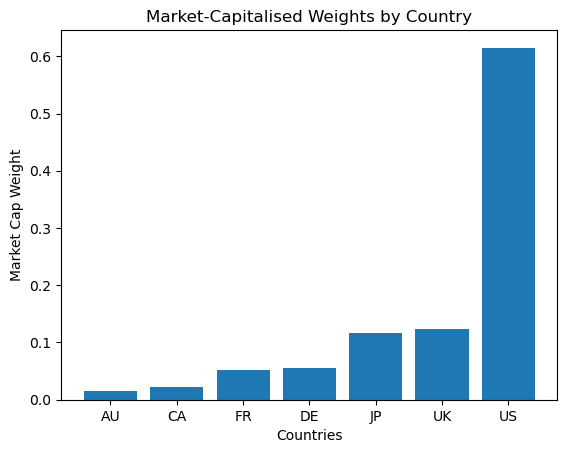

In [6]:
# Bar chart
plt.figure()
plt.bar(market_weights.index, market_weights["CapWeight"])

plt.xlabel("Countries")
plt.ylabel("Market Cap Weight")
plt.title("Market-Capitalised Weights by Country")

plt.show()

In [7]:
# Q
views = [0.05]
# P
pick_list = [
        {
            "DE": 1.0,
            "FR": -market_weights.loc["FR"]/(market_weights.loc["FR"] + \
                                            market_weights.loc["UK"]),
            "UK": -market_weights.loc["UK"] / (market_weights.loc["FR"] + \
                                                market_weights.loc["UK"])
        }
]

P is a matrix K×N where each clumn represent an asset and each lign represent a view

In [11]:
Q = np.array(views)
assets = covariance.columns.tolist()
asset_index = {a: i for i, a in enumerate(assets)}

# Une seule vue → 1 ligne
P = np.zeros((1, len(assets)))

# Vue : DE > portefeuille (FR + UK)
P[0, asset_index["DE"]] = 1.0

w_fr = market_weights.loc["FR", "CapWeight"]
w_uk = market_weights.loc["UK", "CapWeight"]

P[0, asset_index["FR"]] = - w_fr / (w_fr + w_uk)
P[0, asset_index["UK"]] = - w_uk / (w_fr + w_uk)


In [15]:
bl = BlackLittermanModel(
    cov_matrix=covariance,
    P=P,
    Q=Q,
    market_caps=market_weights["CapWeight"],
    tau=0.05,
    risk_aversion=2.5,
    pi="market"
)

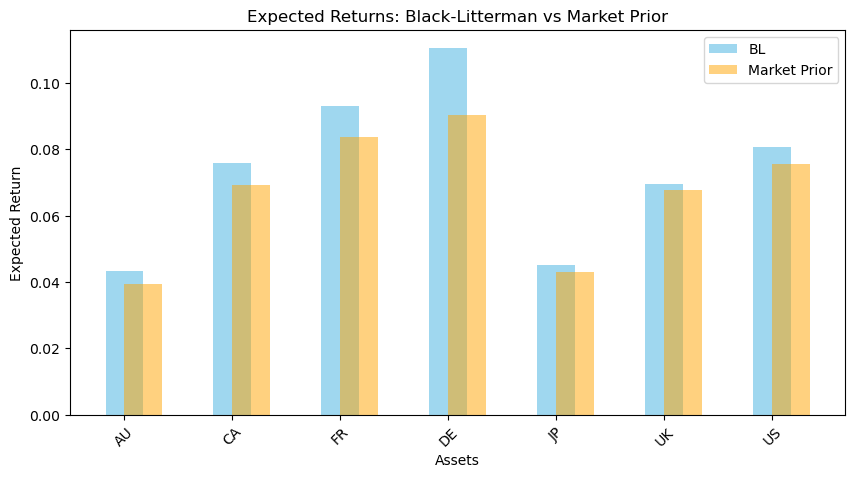

In [20]:


# Rendements implicites du marché (prior)
pi = 2.5 * covariance.dot(market_weights["CapWeight"])
market_returns = pd.Series(pi, index=market_weights.index)



# Expected returns Black-Litterman
bl_returns = bl.bl_returns()



# --- Histogramme des expected returns ---
plt.figure(figsize=(10,5))
width = 0.35  # largeur des barres

plt.bar(bl_returns.index, bl_returns.values, width=width, label="BL", alpha=0.8, color='skyblue')
plt.bar(market_returns.index, market_returns.values, width=width, label="Market Prior", alpha=0.5, color='orange', align='edge')

plt.xlabel("Assets")
plt.ylabel("Expected Return")
plt.title("Expected Returns: Black-Litterman vs Market Prior")
plt.xticks(rotation=45)
plt.legend()
plt.show()




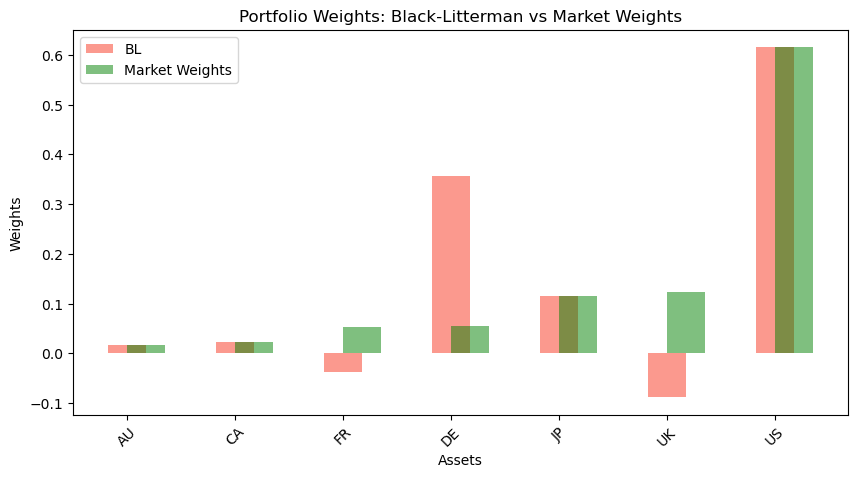

In [23]:
# Poids de marché
market_w = market_weights["CapWeight"]

# Poids optimisés Black-Litterman
weights = bl.bl_weights()
weights = pd.Series(weights)  # weights est un OrderedDict
weights.index.name = "Assets"

# --- Histogramme des poids ---
plt.figure(figsize=(10,5))

plt.bar(weights.index, weights.values, width=width, label="BL", alpha=0.8, color='salmon')
plt.bar(market_w.index, market_w.values, width=width, label="Market Weights", alpha=0.5, color='green', align='edge')

plt.xlabel("Assets")
plt.ylabel("Weights")
plt.title("Portfolio Weights: Black-Litterman vs Market Weights")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [26]:
# Q
views = [0.05, 0.03]
# P
pick_list = [
    {
        "DE": 1.0,
        "FR": -market_weights.loc["FR"]/(market_weights.loc["FR"] + market_weights.loc["UK"]),
        "UK": -market_weights.loc["UK"] / (market_weights.loc["FR"] + market_weights.loc["UK"])
    },
    {
        "CA": 1,
        "US": -1
    }
]


In [27]:
Q = np.array(views)
assets = covariance.columns.tolist()
asset_index = {a: i for i, a in enumerate(assets)}

# 2 vues → 2 ligns
P = np.zeros((2, len(assets)))

# Vue : DE > portefeuille (FR + UK)
P[0, asset_index["DE"]] = 1.0

w_fr = market_weights.loc["FR", "CapWeight"]
w_uk = market_weights.loc["UK", "CapWeight"]

P[0, asset_index["FR"]] = - w_fr / (w_fr + w_uk)
P[0, asset_index["UK"]] = - w_uk / (w_fr + w_uk)

P[1, asset_index["CA"]] = 1.0

P[1, asset_index["US"]] = -1.0

In [28]:
bl = BlackLittermanModel(
    cov_matrix=covariance,
    P=P,
    Q=Q,
    market_caps=market_weights["CapWeight"],
    tau=0.05,
    risk_aversion=2.5,
    pi="market"
)

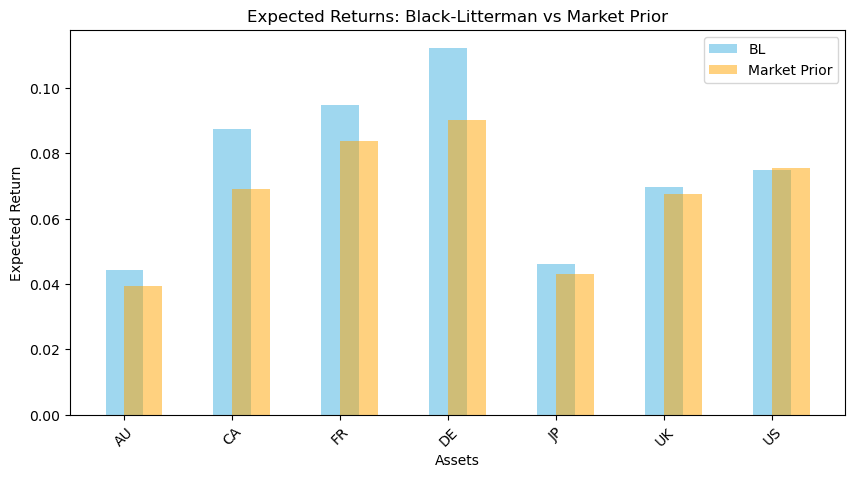

In [29]:
# Rendements implicites du marché (prior)
pi = 2.5 * covariance.dot(market_weights["CapWeight"])
market_returns = pd.Series(pi, index=market_weights.index)



# Expected returns Black-Litterman
bl_returns = bl.bl_returns()



# --- Histogramme des expected returns ---
plt.figure(figsize=(10,5))
width = 0.35  # largeur des barres

plt.bar(bl_returns.index, bl_returns.values, width=width, label="BL", alpha=0.8, color='skyblue')
plt.bar(market_returns.index, market_returns.values, width=width, label="Market Prior", alpha=0.5, color='orange', align='edge')

plt.xlabel("Assets")
plt.ylabel("Expected Return")
plt.title("Expected Returns: Black-Litterman vs Market Prior")
plt.xticks(rotation=45)
plt.legend()
plt.show()

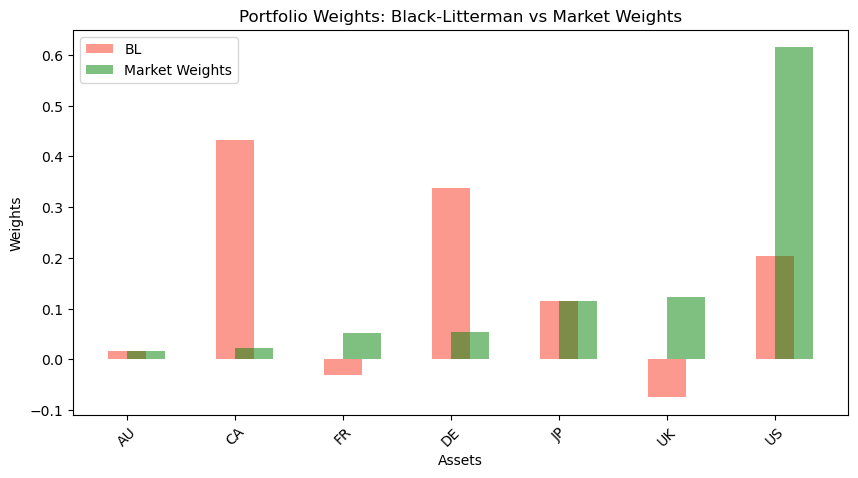

In [30]:
# Poids de marché
market_w = market_weights["CapWeight"]

# Poids optimisés Black-Litterman
weights = bl.bl_weights()
weights = pd.Series(weights)  # weights est un OrderedDict
weights.index.name = "Assets"

# --- Histogramme des poids ---
plt.figure(figsize=(10,5))

plt.bar(weights.index, weights.values, width=width, label="BL", alpha=0.8, color='salmon')
plt.bar(market_w.index, market_w.values, width=width, label="Market Weights", alpha=0.5, color='green', align='edge')

plt.xlabel("Assets")
plt.ylabel("Weights")
plt.title("Portfolio Weights: Black-Litterman vs Market Weights")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In this small Black-Litterman model, we combined market equilibrium data (market-capitalized weights and covariance matrix) with investor views about certain countries’ expected outperformance.

The code calculates:

Expected returns adjusted for views (bl_returns)

Optimal portfolio weights (bl_weights) that reflect both market equilibrium and the investor’s opinions

This approach is useful because it allows us to blend objective market information with subjective insights, producing a well-diversified portfolio that accounts for both market risk and the investor’s beliefs, while avoiding extreme allocations typical of a standard mean-variance optimization.